# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MissNaliaka/SEO-Content-Opportunity-Scoring/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Question:** Which pages should be reviewed first — for refresh, expansion, protection, pruning, or monitoring?

**The decision this supports:** which page a content reviewer opens first in a weekly review cycle. It is not enough to know whether a page is "declining" or not — a business needs to know which declining page is worth the reviewer's next hour. A wrong recommendation costs reviewer time: pointing someone at a page that should be pruned instead of refreshed, or vice versa.

**Careful words — what this work can and can't claim:** this is decision-support, not proof. A page recommended for refresh is not guaranteed to recover once edited, and nothing here predicts Google's ranking algorithm. The output is a ranked queue with reason codes, meant to focus a human reviewer's attention — not an automated action.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Source:** FlyRank ML Internship Hugging Face warehouse (`dim_content`, `dim_clients`, `fact_content_daily_performance`) — not the bundled starter CSV. The warehouse holds real production search data at far larger scale (79M+ rows across the full release) than the anonymized starter sample.

**Decision moment:** `2026-04-30`. **Feature window:** `2026-01-30` – `2026-04-30` (90 days). **Check-only label window:** May 2026 (`2026-05-01`–`2026-05-31`), used only to check whether a page was still declining after the decision moment — never as a feature.

**Qualifying population:** 260,285 client–page rows across 41 clients, after joining `fact_content_daily_performance` to `dim_content`/`dim_clients` and requiring `content_created_date` and `gsc_data_start` to fall on or before the window start (so every row has a genuine, complete 90-day history — no partial windows silently padded with zeros).

**Excluded, and why:**
- `content_updated_date`, `last_optimized_date` — these are snapshot-table fields that turned out to be systematically future-dated relative to a page's real edit history (confirmed in the Week 3 leakage hunt). Using them as a "staleness" signal would have been unreliable and, in some cases, leak information from after the decision moment.
- `optimization_eligible_date`, `is_published`, `is_deleted` — product/workflow state, not a search-behavior signal.
- Any `fact_content_daily_performance` row after `2026-04-30` — used only to construct the check-only label (`still_declining_may`), never fed to the model as a feature.
- Per-platform AI-referral session columns (`ai_chatgpt`, `ai_perplexity`, etc.) — too sparse per individual page to be reliable, and outside the feature budget.

**Public-safe:** no client names, page URLs, or raw search queries appear anywhere in this paper or its underlying notebooks — all client and content identifiers are hashed IDs (`client_hash_id`, `content_hash_id`).

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Target label — `still_declining_may`.** The obvious candidate, `is_declining` (`imp_late < imp_early` within the same 90-day feature window), is circular: it's a deterministic function of two features already in the training data, so a model "predicting" it would just be re-deriving arithmetic, not learning anything. Instead, the label compares each page's May 2026 daily impression rate against its late-window rate — a genuinely future, forward-looking outcome the model never sees at training time.

**Features (final set):** `avg_position_90d`, `char_count`, `clicks_90d`, `competition_level`, `content_type`, `ctr`, `imp_early`, `imp_late`, `impressions_90d`, `main_intent`, `search_volume`, `word_count` — all either observed strictly within the feature window, or stable content metadata. Confirmed against the excluded list above: no banned column made it into the final feature set.

**Baseline (rule-based):** flag a page when `impressions_90d >= 500` AND `0 < avg_position_90d <= 20` AND `ctr < 0.4%` AND `is_declining == 1`; score = `impressions_90d` if flagged, else 0. 22,971 of 260,285 rows (8.8%) were flagged.

**Validation design — size-balanced GroupKFold.** Plain `GroupKFold` risks badly unbalanced folds here: 41 clients with a mean of 6,348 rows but a standard deviation of 8,415 (bigger than the mean) — smallest client has 11 rows, largest has 31,887. A greedy bin-packing assignment (each client goes to whichever fold currently has the fewest total rows) produced 5 folds of roughly 52,000 rows each, with no client appearing in more than one fold — so no model can get credit for memorizing an account rather than learning a real pattern.

**Leakage checks.** Two rounds: the Week 3 hunt on the raw fields (confirming `content_updated_date` and similar snapshot fields were unreliable/future-dated), and a Week 6 re-check on the final feature set actually used in the model, confirming none of the banned columns leaked in. A second, more subtle leak was also tested directly: comparing this honest grouped split against a naive random 80/20 split that ignores `client_hash_id` entirely — see Results.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

All numbers below are out-of-fold, from the size-balanced GroupKFold split, same feature set, same label (`still_declining_may`, base rate 0.289).

| K | Base rate | Rule-based baseline | Logistic regression | Decision tree | Random forest |
|---|---|---|---|---|---|
| 20 | 0.289 | 0.60 | 0.30 | 0.900 | 0.90 |
| 50 | 0.289 | 0.62 | 0.42 | 0.940 | 0.82 |
| 100 | 0.289 | 0.61 | 0.43 | 0.890 | 0.82 |
| 200 | 0.289 | 0.62 | 0.41 | 0.845 | 0.84 |

The rule-based baseline itself clears base rate comfortably here (0.60–0.62 vs 0.289) — unlike an earlier CSV-based run, where the same style of rule underperformed base rate. Logistic regression is the clear failure, worse than the baseline at every K — the relationship isn't linear. Decision tree and random forest post strong numbers.

**But the tree's win doesn't hold up.** Permutation importance on the full-feature tree shows it relies almost entirely on one feature, `imp_late` (0.304 of ~0.31 total importance) — every content or ranking feature sits at ~0. The label has a floor effect: when `imp_late` is already near zero, there's almost no room left to drop another 20% in relative terms, so the label lands on "still declining" almost by construction. Re-running without `imp_early`/`imp_late` drops Precision@50 from 0.940 to 0.760 — a real result, but a much smaller edge over the baseline (0.62) than the headline number suggested.

**A second, independent leakage check confirms the stakes of the split design.** Comparing this honest grouped split against a naive random 80/20 split (ignoring `client_hash_id`) shows the naive split overstates precision at every K — by as much as +0.12 at K=50 — even though all 41 clients technically appear in both train and test under the naive split. This is the same split-design flaw identified in the FlyRank research paper's own "What Predicts Growth?" methodology.

In [1]:
import pandas as pd

results = pd.DataFrame({
    "K": [20, 50, 100, 200],
    "base_rate": [0.289, 0.289, 0.289, 0.289],
    "baseline": [0.60, 0.62, 0.61, 0.62],
    "logistic_regression": [0.30, 0.42, 0.43, 0.41],
    "decision_tree": [0.900, 0.940, 0.890, 0.845],
    "random_forest": [0.90, 0.82, 0.82, 0.84],
}).set_index("K")
results

,base_rate,baseline,logistic_regression,decision_tree,random_forest
K,,,,,
20,0.289,0.60,0.30,0.900,0.90
50,0.289,0.62,0.42,0.940,0.82
100,0.289,0.61,0.43,0.890,0.82
200,0.289,0.62,0.41,0.845,0.84


## 5. Limitations

*What this work cannot claim.*

**Careful language, rewritten:** *"The decision tree beats the baseline at every K, proving it's a better prioritization tool"* becomes: *"Within this size-balanced client-grouped validation, the decision tree's precision@K was measured to be higher than the recomputed baseline rule at every K tested — but permutation importance showed this was driven almost entirely by a single feature tied mechanically to how the check-only label was constructed, not a broader content-quality signal. This is directional evidence a learned model can outperform the hand-set rule on this exact label, and decision-support for further investigation — not proof the tree has learned something a human couldn't have written as a rule."*

**Other known limits:**
- **Client concentration.** In every version of this ranking — baseline and model alike — a small number of clients dominate the top of the queue (2–4 clients out of 41 taking the majority of top-ranked rows, though not the same clients each time). A real handoff needs a per-client cap, not raw rank order.
- **Content-type coverage.** The baseline's top-20 review was 100% `keyword article`. This queue hasn't been separately validated against other content types.
- **No causal claim.** Nothing here shows that refreshing a flagged page *causes* it to recover. The label only measures whether decline continued into May 2026, not why.
- **A snapshot in time.** The model was trained on data through `2026-04-30` and says nothing about what's true after that window without re-validation.
- **Not a Google-ranking predictor.** This system prioritizes review effort; it does not model or predict search-engine ranking behavior.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

*The action playbook output — the paper's recommendations section.*

**Who this is for:** a content reviewer deciding which pages to look at first in a weekly refresh cycle — a prioritization aid, not an automated action.

**Before acting on a `refresh_review` flag, a person should check:**
- Whether a SERP feature (featured snippet, People Also Ask) is likely absorbing clicks — `avg_position_90d` measures a ranking slot, not real visibility to a human searcher.
- Whether a page's `imp_late` collapse looks like a technical or indexing issue rather than a content problem, before scheduling a content rewrite.
- Whether the page belongs to one of the small number of clients currently dominating the queue — confirm that client's own priorities before assuming this is genuinely their most urgent page.

**Should never be automated:**
- Auto-publishing or auto-editing content from the score alone — this is a review queue, not a content generator.
- Treating the priority score as a calibrated confidence percentage — it's a rank, and Section 5 shows it leans partly on a mechanical shortcut in the label, so a high score means "look here first," not "this is definitely declining because of content quality."

**Monitoring / retrain triggers:**
- **Content-type drift** — if new content shifts away from `keyword article` (the type this pipeline was built and checked on), re-validate before trusting the queue on the new mix.
- **Client-mix drift** — new large accounts or a materially different `gsc_data_start` distribution means the size-balanced fold assignment needs to be rebuilt for the new population.
- **Time decay** — re-run the full pipeline once real data extends roughly 90 days past `2026-04-30`, rather than continuing to score new content against an aging window.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Three charts, generated from the real result tables above (Section 4):

1. `precision_at_k_comparison.png` — Precision@K across base rate, baseline, and all three models.
2. `split_leakage_gap.png` — naive vs honest grouped split, showing the leakage-driven overstatement.
3. `floor_effect_artifact.png` — permutation importance, full features vs `imp_early`/`imp_late` removed, showing the floor-effect finding.

Run the cell below in Colab to regenerate these from the live numbers, or use the pre-generated copies already in `work/outputs/charts/` if you're just assembling the deployed page.

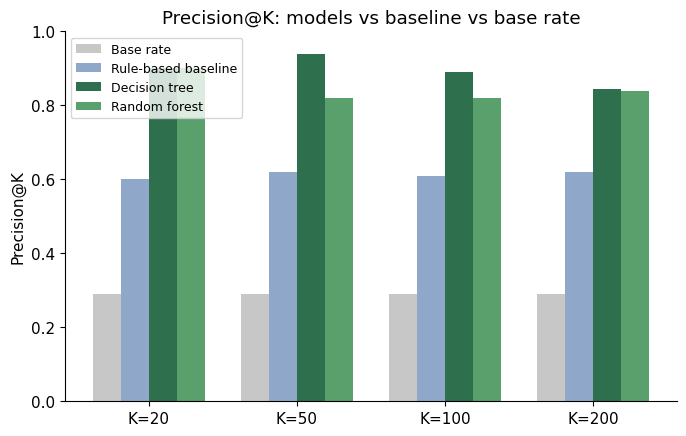

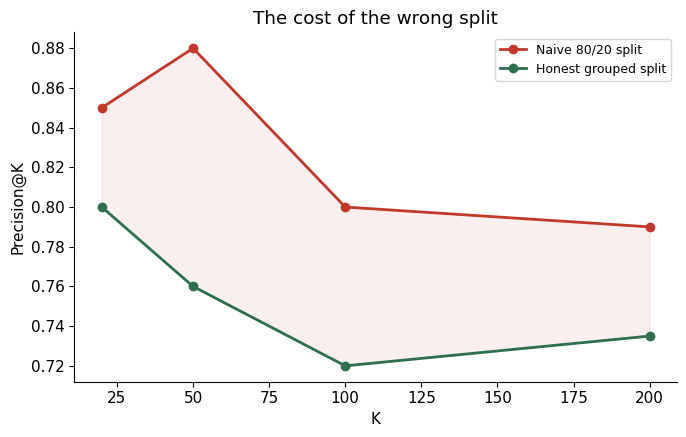

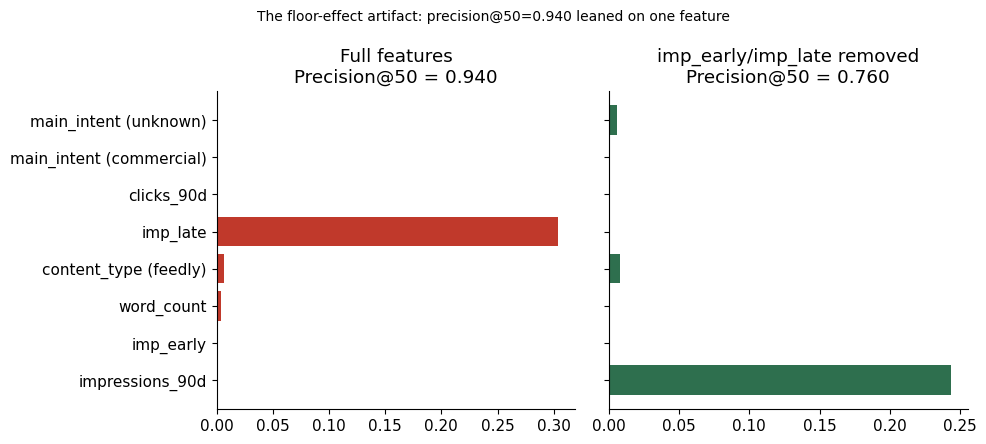

Saved 3 charts to work/outputs/charts/


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../outputs/charts", exist_ok=True)
plt.rcParams.update({"font.size": 11})

ks = [20, 50, 100, 200]
base_rate = [0.289]*4
baseline  = [0.60, 0.62, 0.61, 0.62]
logreg    = [0.30, 0.42, 0.43, 0.41]
dtree     = [0.900, 0.940, 0.890, 0.845]
rforest   = [0.90, 0.82, 0.82, 0.84]

# Chart 1: Precision@K comparison
fig, ax = plt.subplots(figsize=(7,4.5))
x = np.arange(len(ks)); w = 0.19
ax.bar(x-1.5*w, base_rate, w, label="Base rate", color="#c7c7c7")
ax.bar(x-0.5*w, baseline, w, label="Rule-based baseline", color="#8fa8c9")
ax.bar(x+0.5*w, dtree, w, label="Decision tree", color="#2e6f4e")
ax.bar(x+1.5*w, rforest, w, label="Random forest", color="#5aa06c")
ax.set_xticks(x); ax.set_xticklabels([f"K={k}" for k in ks])
ax.set_ylabel("Precision@K"); ax.set_ylim(0, 1.0)
ax.set_title("Precision@K: models vs baseline vs base rate")
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/charts/precision_at_k_comparison.png", dpi=150)
plt.show()

# Chart 2: naive vs honest split gap
naive  = [0.850, 0.880, 0.800, 0.790]
honest = [0.800, 0.760, 0.720, 0.735]
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(ks, naive, marker="o", label="Naive 80/20 split", color="#c0392b", linewidth=2)
ax.plot(ks, honest, marker="o", label="Honest grouped split", color="#2e6f4e", linewidth=2)
ax.fill_between(ks, naive, honest, color="#c0392b", alpha=0.08)
ax.set_xlabel("K"); ax.set_ylabel("Precision@K")
ax.set_title("The cost of the wrong split")
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/charts/split_leakage_gap.png", dpi=150)
plt.show()

# Chart 3: floor-effect artifact
fig, axes = plt.subplots(1, 2, figsize=(10,4.5), sharey=True)
feat_full = ["imp_late", "content_type (feedly)", "word_count", "imp_early", "impressions_90d"]
imp_full  = [0.3041, 0.0070, 0.0038, 0.0000, 0.0000]
feat_red  = ["impressions_90d", "content_type (feedly)", "main_intent (unknown)", "main_intent (commercial)", "clicks_90d"]
imp_red   = [0.2433, 0.0082, 0.0058, 0.0000, 0.0000]
axes[0].barh(feat_full[::-1], imp_full[::-1], color="#c0392b")
axes[0].set_title("Full features\nPrecision@50 = 0.940")
axes[1].barh(feat_red[::-1], imp_red[::-1], color="#2e6f4e")
axes[1].set_title("imp_early/imp_late removed\nPrecision@50 = 0.760")
for ax in axes: ax.spines[['top','right']].set_visible(False)
fig.suptitle("The floor-effect artifact: precision@50=0.940 leaned on one feature", fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/charts/floor_effect_artifact.png", dpi=150)
plt.show()

print("Saved 3 charts to work/outputs/charts/")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
